In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from scipy import stats

In [3]:
df = pd.read_csv("insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()
df.describe()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
# Encode categorical variables
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

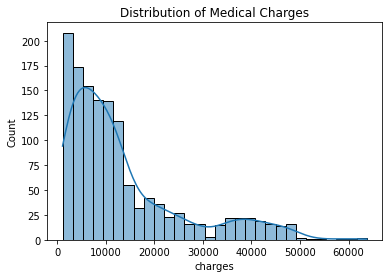

In [7]:
# Distribution of Medical Charges--Shows how healthcare costs are distributed.

sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Medical Charges")
plt.show()

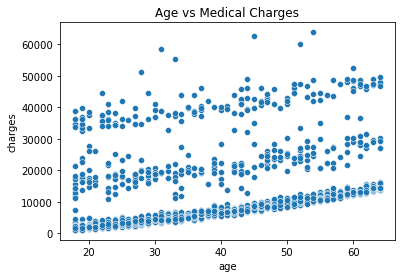

In [12]:
# Age vs Healthcare Cost -- Older people usually have higher healthcare costs
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Medical Charges")
plt.show()




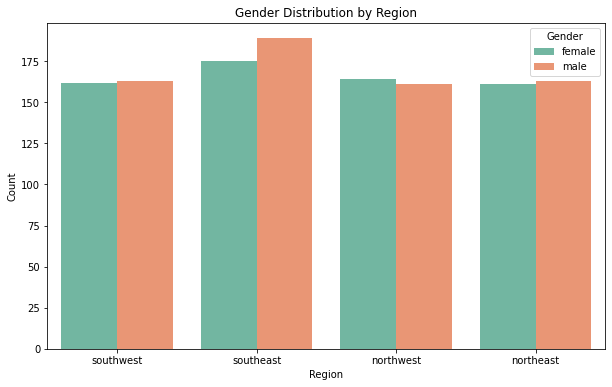

In [15]:
# Gender distribution by region (counts)
plt.figure(figsize=(10,6))
sns.countplot(x="region", hue="sex", data=df, palette="Set2")
plt.title("Gender Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.legend(title="Gender")
plt.show()

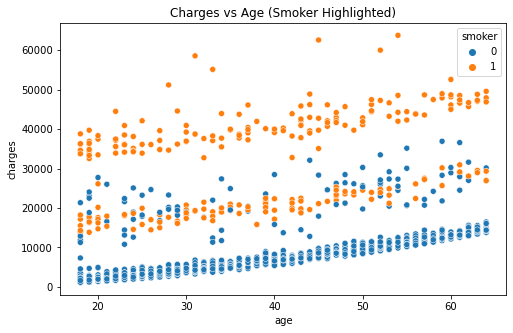

In [13]:
# Age VS Charges
plt.figure(figsize=(8,5))
sns.scatterplot(x="age", y="charges", hue="smoker", data=df)
plt.title("Charges vs Age (Smoker Highlighted)")
plt.show()

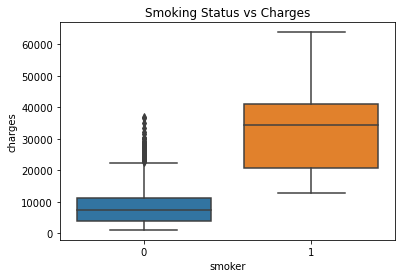

In [64]:
# Smoking vs Healthcare Charges
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoking Status vs Charges")
plt.show()


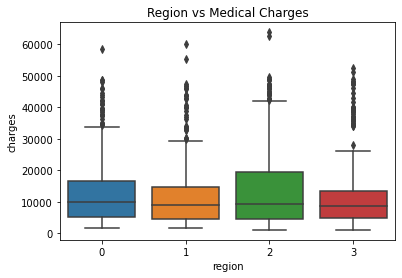

In [65]:
# Region-wise Healthcare Cost -- Compare healthcare costs across different regions.
sns.boxplot(x='region', y='charges', data=df)
plt.title("Region vs Medical Charges")
plt.show()



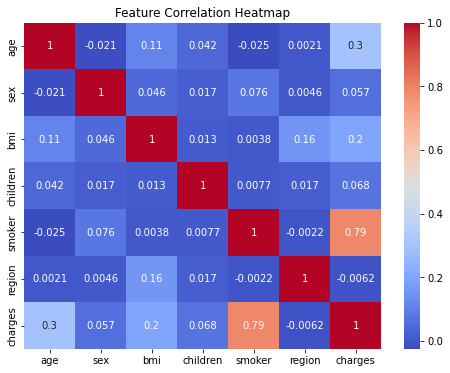

In [66]:
# Correlation Heatmap -- Shows which features influence medical costs the most.
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


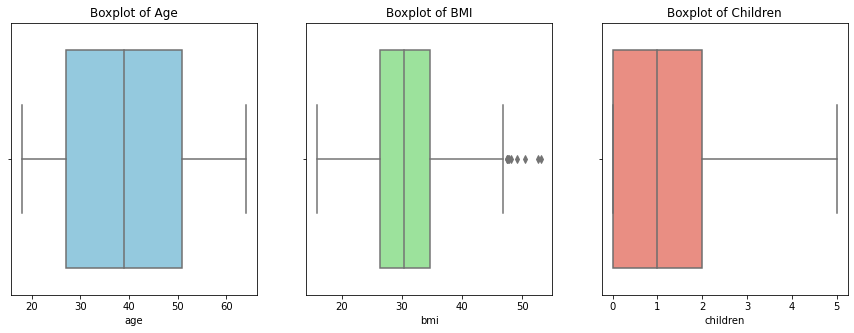

In [14]:
#Outlier Detection
# Outliner Detection
df = pd.read_csv("insurance.csv")
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(x=df['age'],color = 'skyblue')
plt.title('Boxplot of Age')

plt.subplot(1,3,2)
sns.boxplot(x=df['bmi'],color = 'lightgreen')
plt.title('Boxplot of BMI')

plt.subplot(1,3,3)
sns.boxplot(x=df['children'],color = 'salmon')
plt.title('Boxplot of Children')
plt.show()

In [72]:
# IQR Method
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df[(df['charges'] < lower) | (df['charges'] > upper)]
print("Number of Outliers (IQR):", len(outliers_iqr))

Number of Outliers (IQR): 139


In [73]:
# Z-score Method
z_scores = np.abs(stats.zscore(df['charges']))
outliers_z = df[z_scores > 3]
print("Number of Outliers (Z-score):", len(outliers_z))

Number of Outliers (Z-score): 7


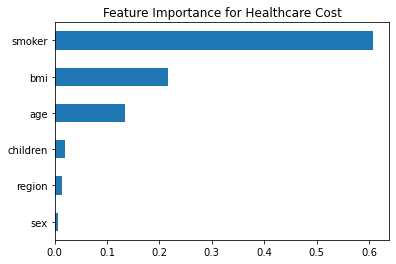

In [75]:
# Feature Importance (Random Forest)
X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance for Healthcare Cost")
plt.show()